# Mushroom Toxicity Classifier — an interpretable decision tree

Classifying mushrooms as edible or poisonous from observable physical characteristics, using a deliberately shallow decision tree so the result can be read as a set of field rules rather than a black box.

The rules are meant to be usable by a person identifying mushrooms, where a wrong answer in one direction is far more costly than in the other.


##Package Imports

Package versions used during execution
1. Pandas: 2.2.2
2. Matplotlib: 3.10.0
3. Seaborn: 0.13.2
4. Scipy: 1.16.3
5. Sklearn: 1.6.1

In [1]:
#import required packages
import matplotlib
import sklearn
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import sklearn.model_selection as skms
import sklearn.tree as skt
import sklearn.metrics as skm

print("Package Versions")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Scipy: {scipy.__version__}")
print(f"Sklearn: {sklearn.__version__}")

Package Versions
Pandas: 2.2.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
Scipy: 1.16.3
Sklearn: 1.6.1


##Data Load and Description

In [2]:
#function for code reproducibility to read dataset
def read_data(fname):
  columns = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat']
  df = pd.read_csv(fname, header=None, names=columns)
  return df

In [3]:
# The UCI Mushroom dataset (agaricus-lepiota.data) is public.
# Place it at data/agaricus-lepiota.data, or set MUSHROOM_DATA to point elsewhere.
import os

fname = os.environ.get(
    "MUSHROOM_DATA",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data",
)

df = read_data(fname)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [4]:
#print first 5 entries from movies datframe to see how data is structured
df.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [5]:
#print dataframe description to see how many unique categories are present for each fature
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


The dataset agaricus-lepiota-data.txt contains features about 8124 hypothetical mushroom samples of 23 species. A column of focus here is class which states if the mushrooms is edible or poisonous and the various visual (eg. cap-color), olfactory (eg. odor) and geogrophical (eg. habitat) features.

##Data Preparation

In [6]:
#Check if there are any duplicate entries in the dataset
print(f"Count of duplicate rows: {len(df[df.duplicated() == True])}")

Count of duplicate rows: 0


In [7]:
#Check if any null values are present in the dataset
if(df.isnull().values.any()):
  print("NaN values are present")
else:
  print("NaN values are not present")


NaN values are not present


In [8]:
#cleaning '?' entries from stalk-root column
print(f"Count of invalid character '?' in stalk-root column to be cleaned: {len(df[df['stalk-root'] == '?'])}")
df['stalk-root'] = df['stalk-root'].replace('?', 'm')
print(f"Unique Values in stalk-root column after reaplacing '?' with 'm': {df['stalk-root'].unique()}")

Count of invalid character '?' in stalk-root column to be cleaned: 2480
Unique Values in stalk-root column after reaplacing '?' with 'm': ['e' 'c' 'b' 'r' 'm']


In [9]:
#dropping column 'veil-type' as it is constant
print(f"Unique Value in column 'veil-type': {df['veil-type'].unique()}")
df = df.drop('veil-type', axis=1)

Unique Value in column 'veil-type': ['p']


Following data preparation steps were carried out to optimize data quality
1. A duplicate rows check was carried out on the dataset which resulted in zero duplicate rows to be removed.
2. A NaN check was carried out on the dataset which resulted in zero NaN values to be removed.
3. Column stalk-root contained '?' as placeholders which were replaced with 'm' (highlighting keyword missing) for consistency in data.
4. Column veil-type which contained only one constant character 'p' was dropped as it would not offer any extra information during analysis.

##Exploratory Analysis for Feature Selection

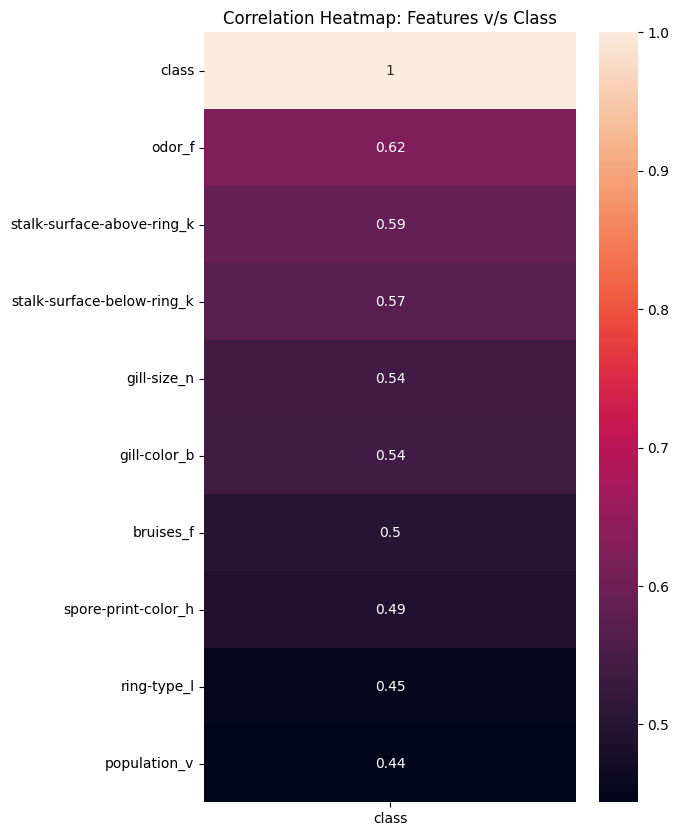

In [10]:
#correlation heatmap of features with class

#copy of dataframe for encoding
df_encoded = df.copy()

#convert 'e','p' class to binary 0 and 1 to ensure that p is 1
df_encoded['class'] = df_encoded['class'].map({'e': 0, 'p': 1})

#one-hot encoding of all features including class
df_encoded = pd.get_dummies(df_encoded)

#construct the correlationmatrix of all the features and keep only top 10 features based on class
df_corr_matrix = df_encoded.corr()
top_corr = df_corr_matrix['class'].sort_values(ascending=False).head(10)
top_corr_df = pd.DataFrame(top_corr)

#plot heatmap
plt.figure(figsize=(6, 10))
sns.heatmap(top_corr_df, annot=True)
plt.title('Correlation Heatmap: Features v/s Class')
plt.show()

The above correlation heatmap clearly show that features like odor, stalk surface above ring, stalk surface below ring, etc are heavily correlated with being poison (since edible = 0 and poison = 1) as their values are closer to 1. A mushroom with f (foul) odour has a highly increased chance of being poisonous. Similarly, stalk surface above ring of texture type s (silky) is also highly correlated with being poisonous.

Attribute information from agaricus-lepiota-info.text for reference -
```
     1. cap-shape:                bell=b,conical=c,convex=x,flat=f,
                                  knobbed=k,sunken=s
     2. cap-surface:              fibrous=f,grooves=g,scaly=y,smooth=s
     3. cap-color:                brown=n,buff=b,cinnamon=c,gray=g,green=r,
                                  pink=p,purple=u,red=e,white=w,yellow=y
     4. bruises?:                 bruises=t,no=f
     5. odor:                     almond=a,anise=l,creosote=c,fishy=y,foul=f,
                                  musty=m,none=n,pungent=p,spicy=s
     6. gill-attachment:          attached=a,descending=d,free=f,notched=n
     7. gill-spacing:             close=c,crowded=w,distant=d
     8. gill-size:                broad=b,narrow=n
     9. gill-color:               black=k,brown=n,buff=b,chocolate=h,gray=g,
                                  green=r,orange=o,pink=p,purple=u,red=e,
                                  white=w,yellow=y
    10. stalk-shape:              enlarging=e,tapering=t
    11. stalk-root:               bulbous=b,club=c,cup=u,equal=e,
                                  rhizomorphs=z,rooted=r,missing=?
    12. stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s
    13. stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s
    14. stalk-color-above-ring:   brown=n,buff=b,cinnamon=c,gray=g,orange=o,
                                  pink=p,red=e,white=w,yellow=y
    15. stalk-color-below-ring:   brown=n,buff=b,cinnamon=c,gray=g,orange=o,
                                  pink=p,red=e,white=w,yellow=y
    16. veil-type:                partial=p,universal=u
    17. veil-color:               brown=n,orange=o,white=w,yellow=y
    18. ring-number:              none=n,one=o,two=t
    19. ring-type:                cobwebby=c,evanescent=e,flaring=f,large=l,
                                  none=n,pendant=p,sheathing=s,zone=z
    20. spore-print-color:        black=k,brown=n,buff=b,chocolate=h,green=r,
                                  orange=o,purple=u,white=w,yellow=y
    21. population:               abundant=a,clustered=c,numerous=n,
                                  scattered=s,several=v,solitary=y
    22. habitat:                  grasses=g,leaves=l,meadows=m,paths=p,
                                  urban=u,waste=w,woods=d
```




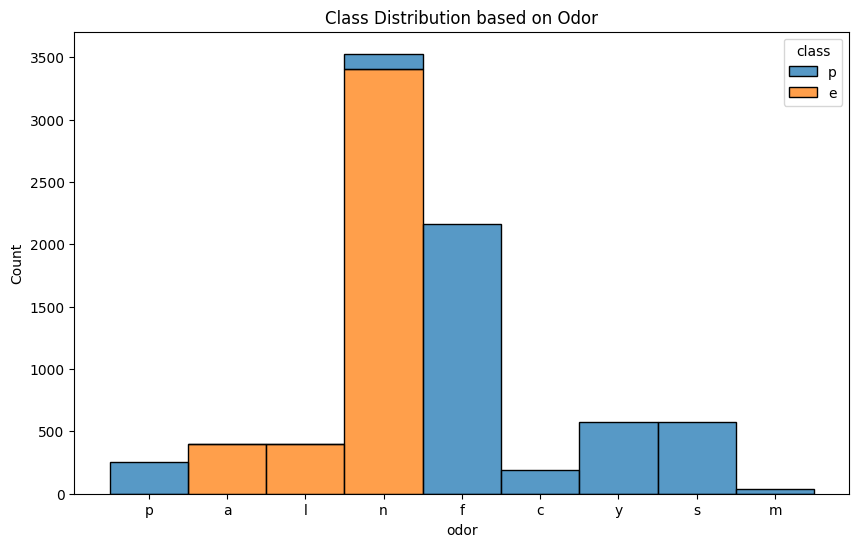

In [11]:
#countplot of odor and class
plt.figure(figsize=(10, 6))
sns.histplot(df,x='odor',hue="class",multiple="stack")
plt.title('Class Distribution based on Odor')
plt.show()

This plot acts as an additional step of confirmation that mushrooms with odor f (foul), y (fishy) and s (spicy) can be instantaneously marked as poisonous. This plot provides more evidence onto why odor would be the best primary feature for this application.

In [12]:
#hypothesis testing (Chi-square) to confirm if 'Odor' is a significant predictor of 'Class'

#Null Hypothesis: Class is independent of feature Odor.
#Alternative Hypothesis: Class is dependent on feature Odor.

#Create odor and class dataframesfor contingency table
df_odor = df['odor']
df_class = df['class']

#Create contingency table to perform the teting
con_table = pd.crosstab(df_odor, df_class)

#perform the chi^2 contingency test
res = ss.chi2_contingency(con_table,correction=False)
print(res)
alpha = 0.05

if res.pvalue < alpha:
    print(f"\nReject the null hypothesis at the {alpha*100}% significance level")
else:
    print(f"\nFail to reject the null hypothesis at the {alpha*100}% significance level")

Chi2ContingencyResult(statistic=np.float64(7659.726740165339), pvalue=np.float64(0.0), dof=8, expected_freq=array([[ 207.18857706,  192.81142294],
       [  99.45051699,   92.54948301],
       [1118.8183161 , 1041.1816839 ],
       [ 207.18857706,  192.81142294],
       [  18.64697194,   17.35302806],
       [1827.40324963, 1700.59675037],
       [ 132.60068932,  123.39931068],
       [ 298.35155096,  277.64844904],
       [ 298.35155096,  277.64844904]]))

Reject the null hypothesis at the 5.0% significance level


A chi^2-contingency hypothesis testing was conducted between feature 'Odor' and 'Class' to statistcally validate the high correlation that was analyzed as part of correlation heatmap and the count plots.

*   H0: Toxicity class is independent of feature Odor.
*   H1: Toxicity class is dependent on feature Odor.

At a significance level of 5%, the null hypothesis was rejected with p-value < 0.001 statistically confirming that 'odor' is a strong predictor of 'class'.

##Model Training

In [13]:
#Decision Tree Classifier

#Target Class encoding. e = 0 and p = 1
y_encoded = df['class'].map({'e': 0, 'p': 1})

#Feature encoding using one-hot encoding method
x_encoded = pd.get_dummies(df.drop('class', axis=1))

#Train/Test data split
x_train, x_test, y_train, y_test = skms.train_test_split(x_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

#Fitting decision tree classifier
model = skt.DecisionTreeClassifier(max_depth=3)
clf = model.fit(x_train,y_train)

#Predict model using the test dataset created
y_pred = clf.predict(x_test)


A decision tree classifier was fit for the given data as this deemed to be the most suitable model for generating a set of sequential rules that a person could follow.

**Class Encoding** - The class column was first manually encoded into 0 (edible) and 1 (poisonous) so that poisonous class would get 1. This manual approach helped in eliminating randomness of poisonous being assigned 0 instead of 1.

**One-Hot Encoding** - The remaining columns other than class was the one-hot encoded so that the data is converted to the way it can be used to train a model.

Both these encoding approaches allowed us to create data in the way it is required for fitting a model where the features is a 2D array and the target variable is a 1D array.

##Model Evaluation

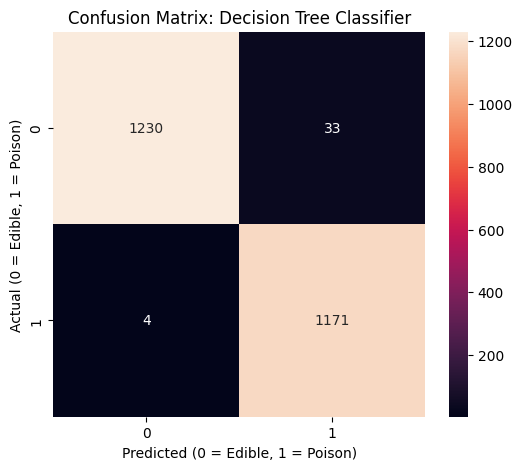

In [14]:
#confusion matrix of the fitted model

#initialize the confusion matrix using
con_m = skm.confusion_matrix(y_test, y_pred)

#plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(con_m, annot=True, fmt='n')
plt.xlabel('Predicted (0 = Edible, 1 = Poison)')
plt.ylabel('Actual (0 = Edible, 1 = Poison)')
plt.title('Confusion Matrix: Decision Tree Classifier')
plt.show()

The above confusion matrix shows that the decision tree classifier model that has been fitted is very accurate as the situation where the model predicted a mushroom as edible where-in it is actually poisonous is extremely minimal (bottom left of the plot) with only 4 hazardous prediction. The diagonal boxes clearly justify that the model was able to predict an actual edible and poisonous mushroom correc 1230 and 1171 times correctly. The top-right quadrant shows that the model predicted 33 actual edible mushrooms as poisonous.
This shows that the model was able to achieve the correct results with very minimal errors.

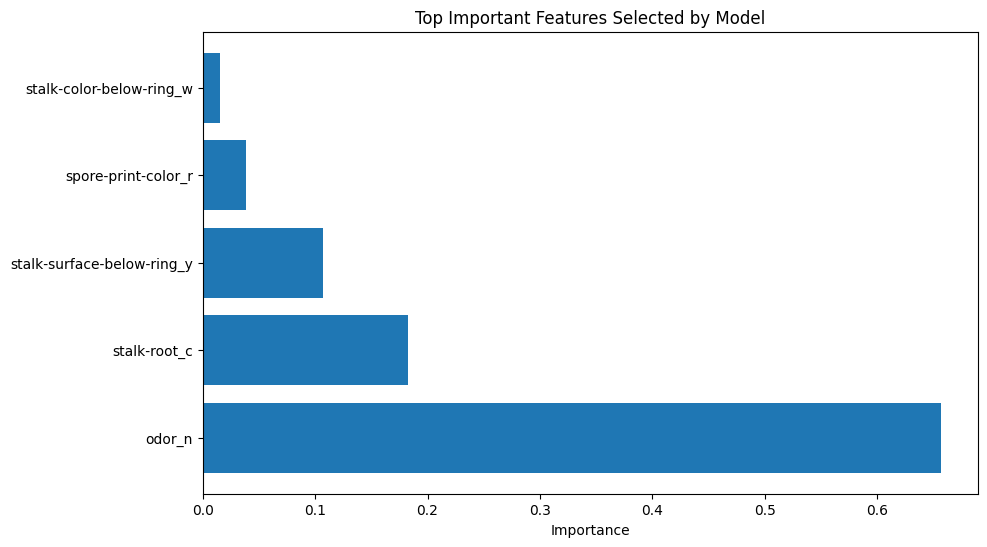

In [15]:
importances = clf.feature_importances_.tolist()
indices = x_encoded.columns.tolist()
top_import = pd.DataFrame({'indices': indices, 'importances': importances}).sort_values(by="importances", ascending=False).head(5)

plt.figure(figsize=(10, 6))
plt.barh(top_import["indices"], top_import["importances"])
plt.title('Top Important Features Selected by Model')
plt.xlabel('Importance')
plt.show()

Looking at the above plot we can confirm that model uses odor as the top important feature for its prediction which is also in-line with the earlier exploratory analysis and hypothesis testing that was carried out. Other features like stalk root, spore print color and stalk-surface-above-ring also shows importance in prediction.

In [16]:
#classfication report
print("Classification Report of the trained Decision Tree Classifier")
print(skm.classification_report(y_test, y_pred, target_names=['edible', 'poisonous']))

Classification Report of the trained Decision Tree Classifier
              precision    recall  f1-score   support

      edible       1.00      0.97      0.99      1263
   poisonous       0.97      1.00      0.98      1175

    accuracy                           0.98      2438
   macro avg       0.98      0.99      0.98      2438
weighted avg       0.99      0.98      0.98      2438



The given classfication report shows that the model has compiled with an accuracy of ~98%. However, this alone cannot be considered in this case as our analysis is highly sensitive to the 4 false negatives highlighted as part of the confusion matrix.

##Result

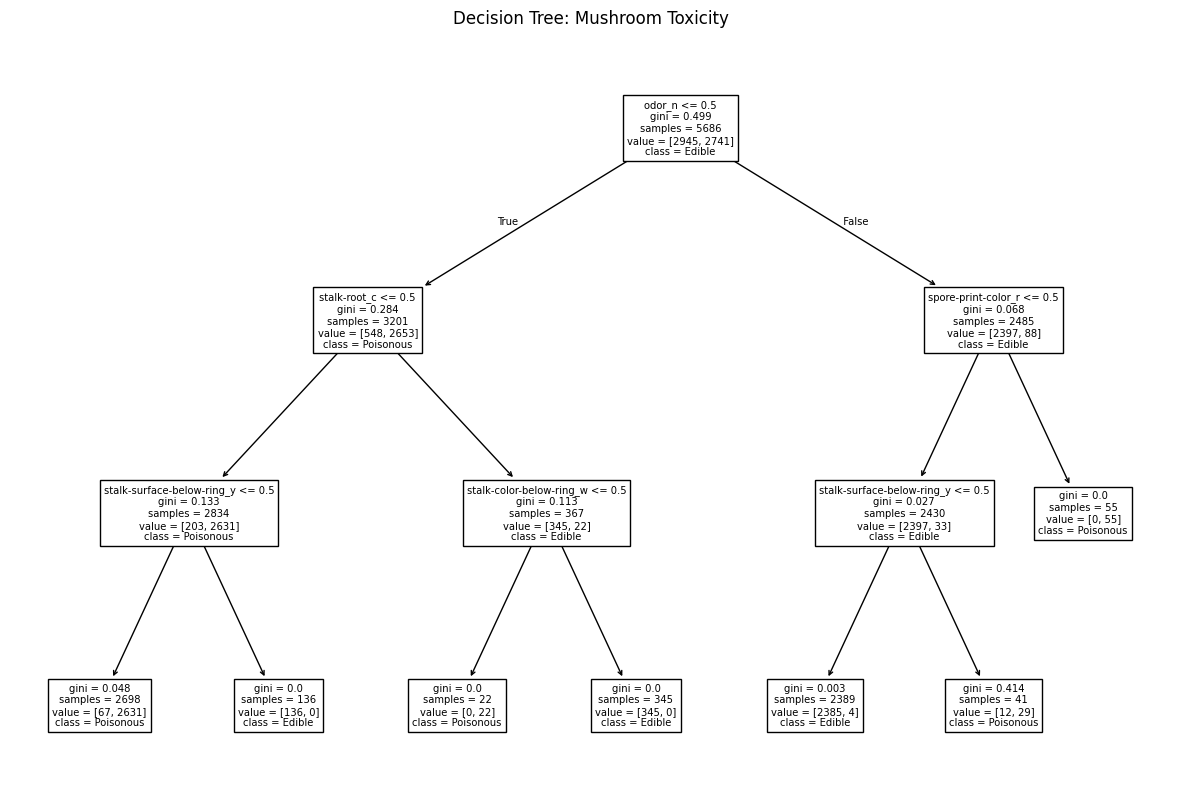

In [17]:
#visually plot the decision tree
plt.figure(figsize=(15, 10))
skt.plot_tree(clf,feature_names=x_encoded.columns, class_names=['Edible', 'Poisonous'])
plt.title("Decision Tree: Mushroom Toxicity")
plt.show()

The final decision tree gives a short set of rules for identifying poisonous mushrooms. Here, odor acts as the primary feature for validating if a mushroom is poisonous or not and other supplementary features such as stalk characteristics and spore print colour help support the prediction.